# Simple OT-Constant Flow Matching

Three datasets run sequentially: **12 discrete circle points**, **2D sphere (uniform disk)**, and **Swiss roll**.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchdyn.core import NeuralODE

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"Using {device} — {torch.cuda.get_device_name(device)}")
else:
    print("Using CPU")

Using cuda:0 — NVIDIA RTX A6000


## Shared utilities

In [2]:
def sample_noise(n):
    return torch.randn(n, 2, device=device)


def ot_constant(x0, x1, t):
    """x_t = t*x1 + (1-t)*x0,  u_t = x1 - x0"""
    t = t[:, None]
    return t * x1 + (1 - t) * x0, x1 - x0


class VelocityMLP(nn.Module):
    def __init__(self, dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden), nn.SELU(),
            nn.Linear(hidden, hidden),  nn.SELU(),
            nn.Linear(hidden, hidden),  nn.SELU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, t, x, args=None):
        if t.dim() == 0:
            t = t.repeat(x.shape[0])
        return self.net(torch.cat([x, t[:, None]], dim=-1))


class ODEWrapper(nn.Module):
    """Broadcast scalar t from torchdyn to batch dimension."""
    def __init__(self, net):
        super().__init__()
        self.net = net

    def forward(self, t, x, args=None):
        return self.net(t.repeat(x.shape[0]), x)

In [3]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})


def train(sample_target_fn, n_steps=50_000, batch_size=256, lr=1e-3, print_every=5_000):
    """Train a fresh VelocityMLP with OT-constant CFM. Returns (model, losses)."""
    model = VelocityMLP().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    t0 = time.time()

    for step in range(1, n_steps + 1):
        x0 = sample_noise(batch_size)
        x1 = sample_target_fn(batch_size).to(device)
        t = torch.rand(batch_size, device=device)

        xt, ut = ot_constant(x0, x1, t)
        loss = ((model(t, xt) - ut) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if step % print_every == 0:
            elapsed = time.time() - t0
            print(f"  step {step:>6d} | loss {loss.item():.4f} | {elapsed:.1f}s")
            t0 = time.time()

    return model, losses


def generate(model, n_samples=2048, n_time=500):
    """Integrate the learned ODE from noise to data. Returns trajectory array."""
    node = NeuralODE(ODEWrapper(model), solver="midpoint", sensitivity="adjoint")
    with torch.no_grad():
        traj = node.trajectory(
            sample_noise(n_samples),
            t_span=torch.linspace(0, 1, n_time, device=device),
        )
    return traj.cpu().numpy()


# ---------------------------------------------------------------------------
#  Plot 1: Training loss (log-scale + linear)
# ---------------------------------------------------------------------------
def plot_loss(losses, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    w = 500
    for i, ax in enumerate(axes):
        ax.plot(losses, alpha=0.12, lw=0.4, c="#2176FF", label="per-step")
        if len(losses) >= w:
            sm = np.convolve(losses, np.ones(w) / w, mode="valid")
            ax.plot(range(w - 1, len(losses)), sm, c="#D7263D", lw=2,
                    label=f"moving avg ({w})")
        ax.set_xlabel("step")
        ax.set_ylabel("MSE loss")
        ax.legend(loc="upper right")
    axes[0].set_title(f"{title} — loss (linear)")
    axes[1].set_yscale("log")
    axes[1].set_title(f"{title} — loss (log)")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#  Plot 2: Time-snapshot evolution  (t = 0, 0.2, 0.4, 0.6, 0.8, 1.0)
# ---------------------------------------------------------------------------
def plot_snapshots(traj, xi, title, times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0)):
    n_times = traj.shape[0]
    n_show = min(1500, traj.shape[1])
    fig, axes = plt.subplots(1, len(times), figsize=(4 * len(times), 4))
    for ax, t_val in zip(axes, times):
        idx = min(int(t_val * (n_times - 1)), n_times - 1)
        ax.scatter(traj[idx, :n_show, 0], traj[idx, :n_show, 1],
                   s=3, alpha=0.5, c="#2176FF", rasterized=True)
        ax.scatter(xi[:, 0], xi[:, 1], s=40, c="red", marker="*",
                   edgecolors="k", linewidths=0.4, zorder=10)
        ax.set_aspect("equal")
        ax.set_title(f"$t = {t_val:.1f}$", fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{title} — distribution snapshots", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#  Plot 3: Individual trajectory paths (lines, not scatter)
# ---------------------------------------------------------------------------
def plot_trajectory_lines(traj, xi, title, n_lines=60):
    n_times = traj.shape[0]
    n_particles = traj.shape[1]
    idx = np.random.choice(n_particles, size=min(n_lines, n_particles), replace=False)
    t_sub = np.arange(0, n_times, max(1, n_times // 200))

    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = plt.cm.coolwarm
    for i in idx:
        colors = t_sub / (n_times - 1)
        for j in range(len(t_sub) - 1):
            ax.plot(traj[t_sub[j]:t_sub[j+1]+1, i, 0],
                    traj[t_sub[j]:t_sub[j+1]+1, i, 1],
                    c=cmap(colors[j]), lw=0.6, alpha=0.6)
    ax.scatter(traj[0, idx, 0], traj[0, idx, 1],
               s=15, c="gray", zorder=5, label="Start ($t{=}0$)")
    ax.scatter(traj[-1, idx, 0], traj[-1, idx, 1],
               s=15, c="#2176FF", zorder=5, label="End ($t{=}1$)")
    ax.scatter(xi[:, 0], xi[:, 1], s=100, c="red", marker="*",
               edgecolors="k", linewidths=0.5, zorder=10, label="Target")
    sm_cb = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm_cb.set_array([])
    cbar = fig.colorbar(sm_cb, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("time $t$", fontsize=10)
    ax.set_aspect("equal")
    ax.set_title(f"{title} — {len(idx)} trajectory paths")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#  Plot 4: Learned vector field (quiver) at several time steps
# ---------------------------------------------------------------------------
def plot_vector_field(model, xi, title, times=(0.0, 0.25, 0.5, 0.75, 0.99),
                      grid_n=20, xlim=(-3, 3), ylim=(-3, 3)):
    xs = np.linspace(xlim[0], xlim[1], grid_n)
    ys = np.linspace(ylim[0], ylim[1], grid_n)
    xx, yy = np.meshgrid(xs, ys)
    grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1),
                        dtype=torch.float32, device=device)

    fig, axes = plt.subplots(1, len(times), figsize=(5 * len(times), 5))
    model.eval()
    with torch.no_grad():
        for ax, t_val in zip(axes, times):
            t_vec = torch.full((grid.shape[0],), t_val, device=device)
            vel = model(t_vec, grid).cpu().numpy()
            u, v = vel[:, 0].reshape(grid_n, grid_n), vel[:, 1].reshape(grid_n, grid_n)
            speed = np.sqrt(u**2 + v**2)
            ax.quiver(xx, yy, u, v, speed, cmap="coolwarm", alpha=0.8,
                      scale=speed.max() * grid_n * 0.8)
            ax.scatter(xi[:, 0], xi[:, 1], s=50, c="red", marker="*",
                       edgecolors="k", linewidths=0.4, zorder=10)
            ax.set_aspect("equal")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_title(f"$t = {t_val:.2f}$", fontsize=12)
    fig.suptitle(f"{title} — learned vector field $v_\\theta(t, x)$",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#  Plot 5: Generated density + distance-to-nearest-target histogram
# ---------------------------------------------------------------------------
def plot_density_and_distance(traj, xi, title):
    gen = traj[-1]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]
    ax.hist2d(gen[:, 0], gen[:, 1], bins=60, cmap="Blues", alpha=0.85, density=True)
    ax.scatter(xi[:, 0], xi[:, 1], s=70, c="red", marker="*",
               edgecolors="white", linewidths=0.6, zorder=10, label="Target")
    ax.set_aspect("equal")
    ax.set_title(f"{title} — generated density (2D histogram)")
    ax.legend(loc="upper right")

    ax = axes[1]
    from scipy.spatial.distance import cdist
    dists = cdist(gen, xi).min(axis=1)
    ax.hist(dists, bins=80, color="#2176FF", alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.axvline(np.median(dists), c="#D7263D", lw=2, ls="--",
               label=f"median = {np.median(dists):.3f}")
    ax.axvline(np.mean(dists), c="#FF8C00", lw=2, ls=":",
               label=f"mean = {np.mean(dists):.3f}")
    ax.set_xlabel("Distance to nearest target point")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} — proximity to targets")
    ax.legend()

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
#  Master function: run all plots for one experiment
# ---------------------------------------------------------------------------
def plot_all(model, traj, xi, losses, title):
    plot_loss(losses, title)
    plot_snapshots(traj, xi, title)
    plot_trajectory_lines(traj, xi, title)
    plot_vector_field(model, xi, title)
    plot_density_and_distance(traj, xi, title)

---
## 1. Twelve discrete points on the unit circle

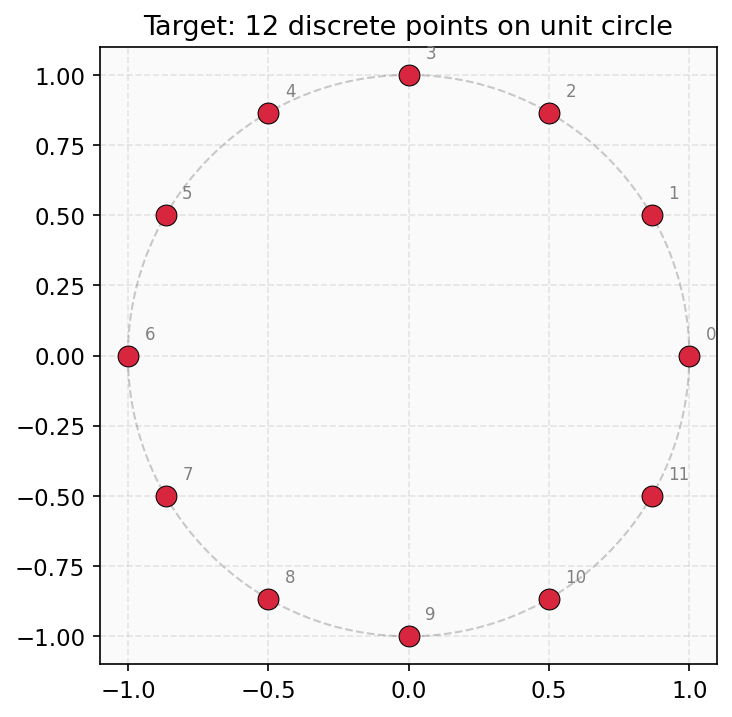

In [4]:
N_PTS = 12
angles = torch.linspace(0, 2 * math.pi, N_PTS + 1)[:-1]
xi_circle = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

def sample_circle_discrete(n):
    return xi_circle[torch.randint(0, N_PTS, (n,))]

fig, ax = plt.subplots(figsize=(5, 5))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), "k--", alpha=0.2, lw=1)
ax.scatter(xi_circle[:, 0], xi_circle[:, 1], s=100, c="#D7263D",
           edgecolors="k", linewidths=0.5, zorder=5)
for i, (x, y) in enumerate(xi_circle.numpy()):
    ax.annotate(str(i), (x, y), textcoords="offset points",
                xytext=(8, 8), fontsize=8, color="gray")
ax.set_aspect("equal")
ax.set_title(f"Target: {N_PTS} discrete points on unit circle")
plt.tight_layout(); plt.show()

Training on 12 discrete circle points ...


  step   5000 | loss 1.0448 | 11.7s


  step  10000 | loss 0.9080 | 12.4s


  step  15000 | loss 0.9469 | 9.7s


  step  20000 | loss 0.9847 | 11.6s


...

  step  30000 | loss 0.8636 | 9.1s


  step  35000 | loss 1.0589 | 10.6s


  step  40000 | loss 0.9904 | 8.3s


  step  45000 | loss 0.9350 | 9.6s


  step  50000 | loss 0.8340 | 10.3s


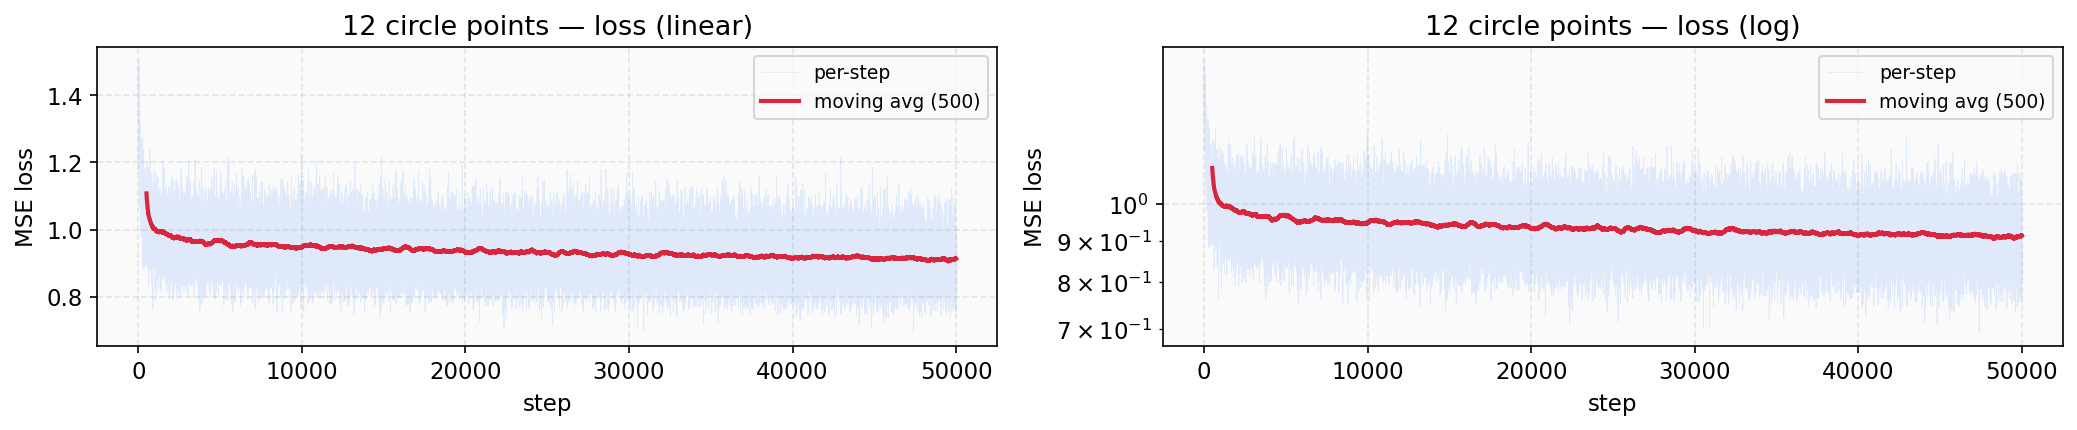

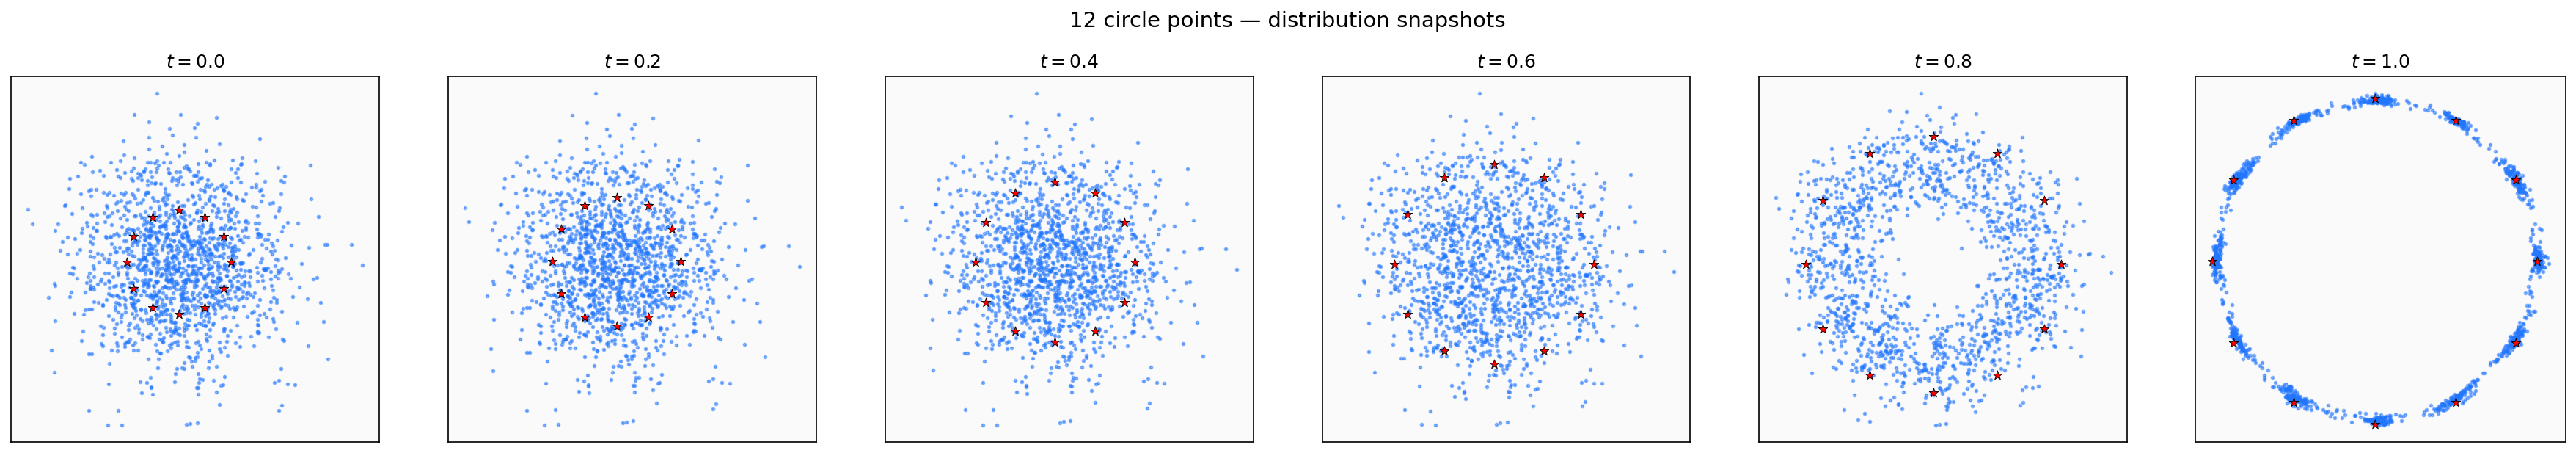

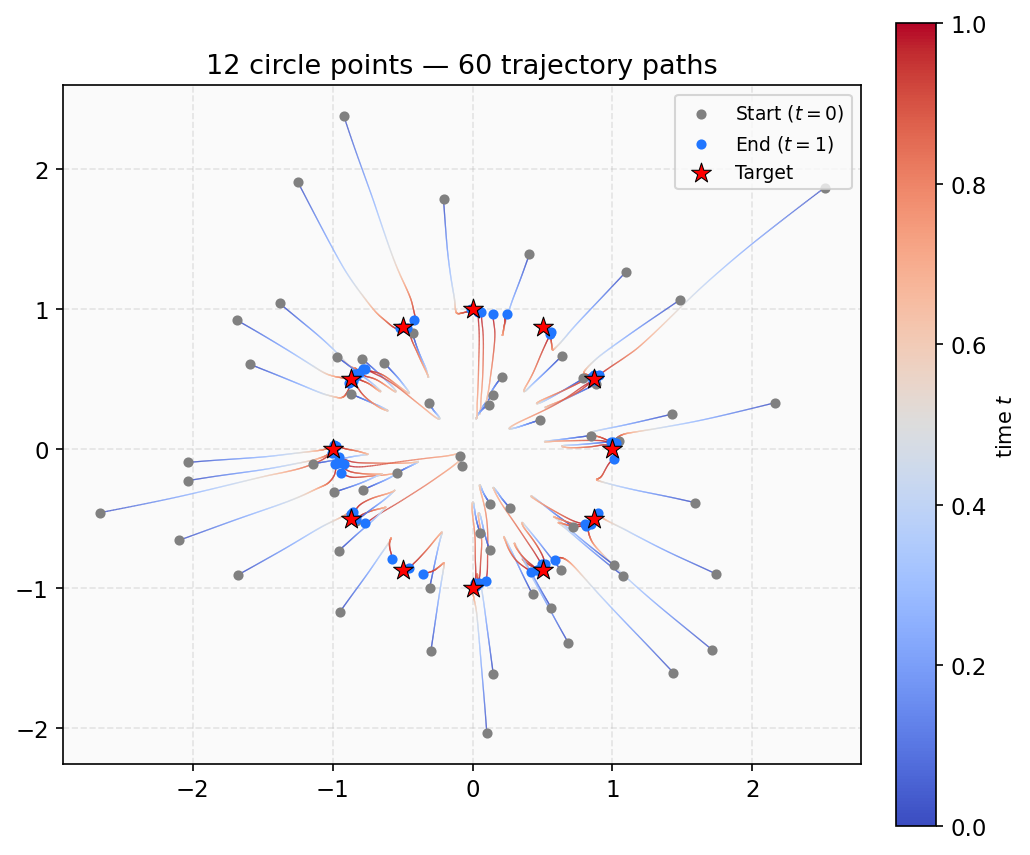

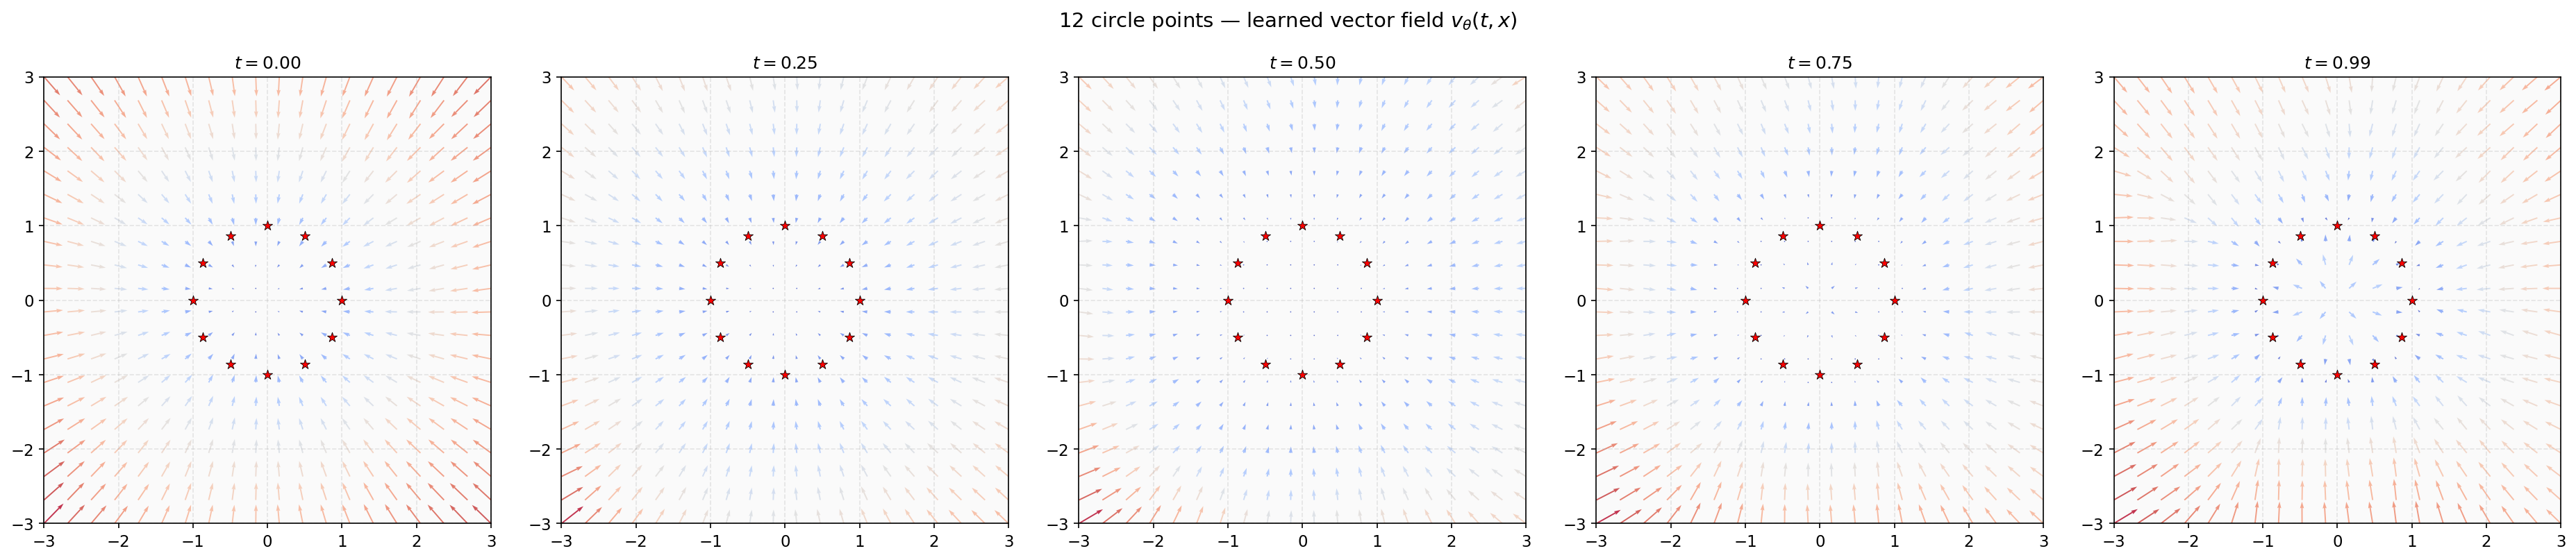

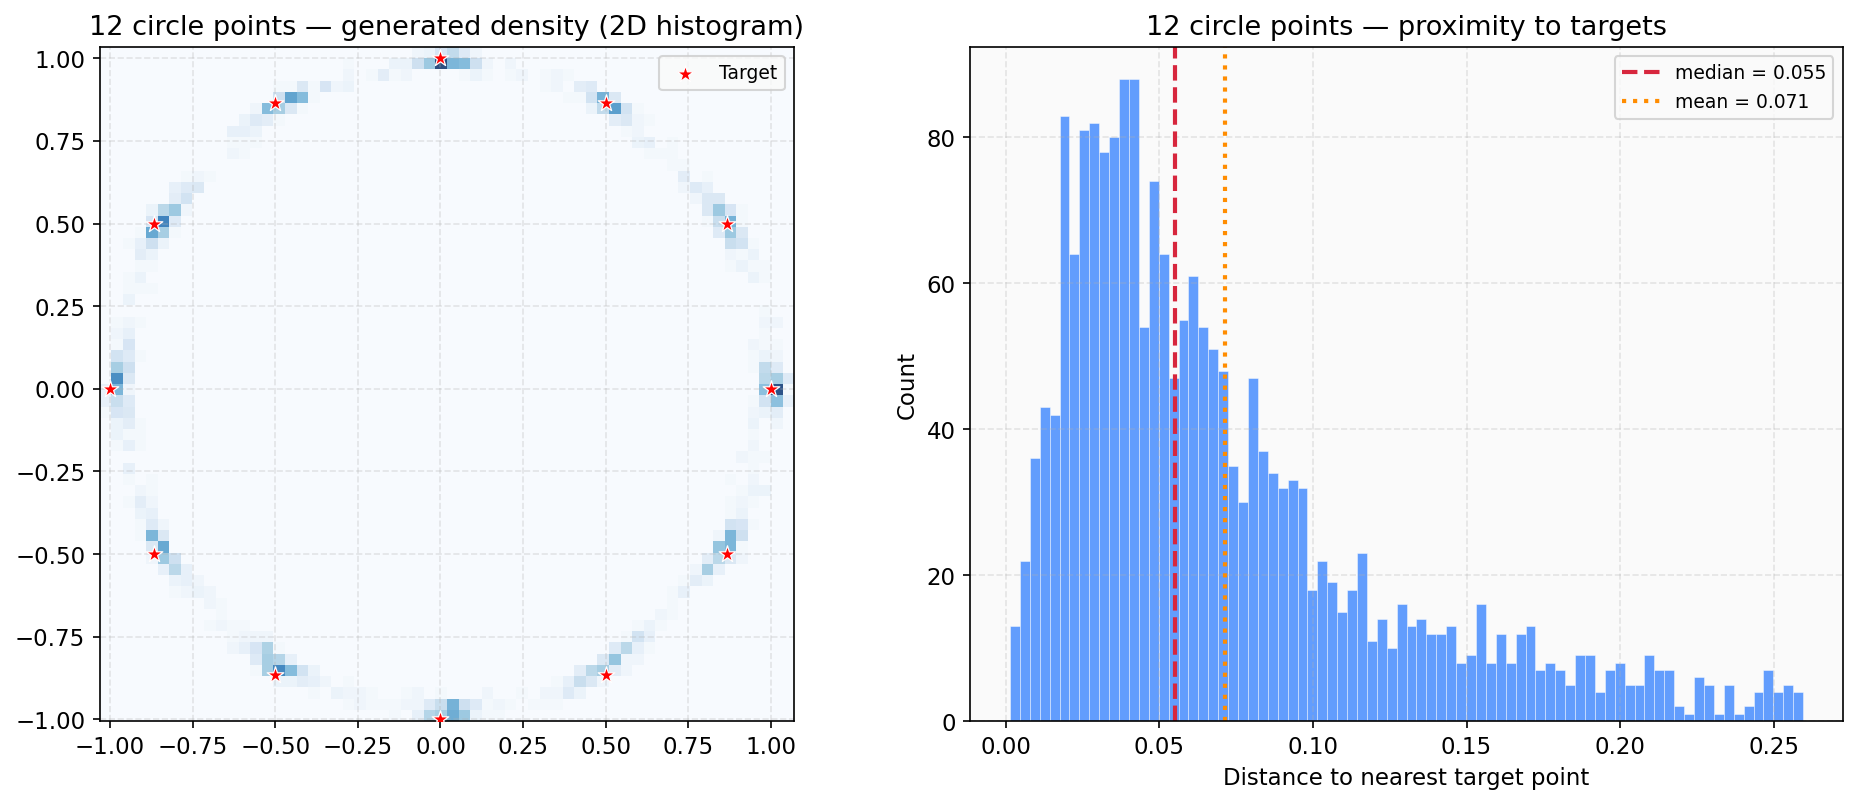

In [5]:
print("Training on 12 discrete circle points ...")
model_1, losses_1 = train(sample_circle_discrete)
traj_1 = generate(model_1)
plot_all(model_1, traj_1, xi_circle.numpy(), losses_1, "12 circle points")

---
## 2. Uniform 2D sphere (filled unit disk)

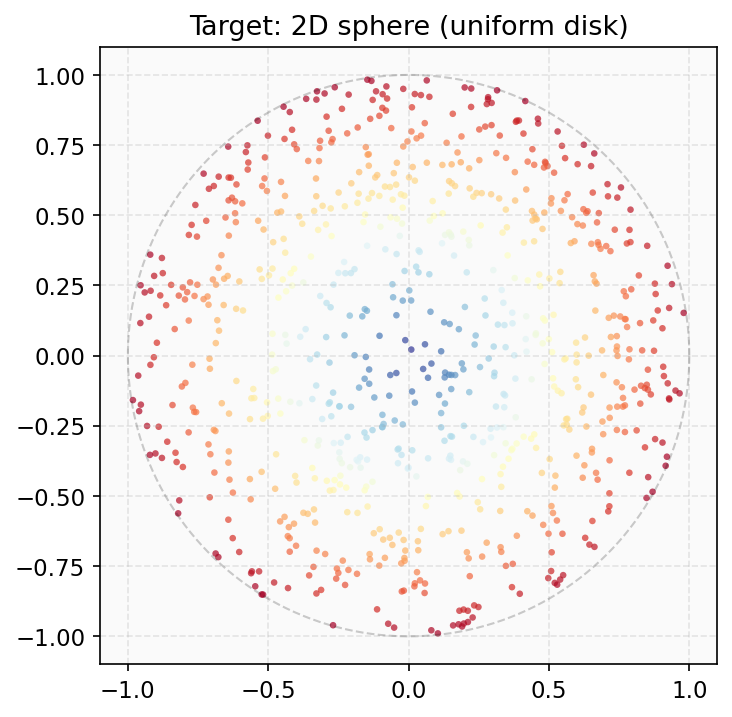

In [6]:
def sample_2d_sphere(n):
    """Sample n points uniformly inside the unit disk using rejection-free polar method."""
    theta = 2 * math.pi * torch.rand(n)
    r = torch.sqrt(torch.rand(n))
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)

xi_sphere = sample_2d_sphere(800).numpy()

fig, ax = plt.subplots(figsize=(5, 5))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), "k--", alpha=0.2, lw=1)
r_vals = np.sqrt(xi_sphere[:, 0]**2 + xi_sphere[:, 1]**2)
ax.scatter(xi_sphere[:, 0], xi_sphere[:, 1], s=10, c=r_vals,
           cmap="RdYlBu_r", alpha=0.7, edgecolors="none")
ax.set_aspect("equal")
ax.set_title("Target: 2D sphere (uniform disk)")
plt.tight_layout(); plt.show()

Training on 2D sphere (uniform disk) ...


  step   5000 | loss 0.7488 | 11.0s


  step  10000 | loss 0.7323 | 9.9s


  step  15000 | loss 0.7272 | 10.6s


  step  20000 | loss 0.7923 | 10.5s


...

  step  30000 | loss 0.7480 | 12.7s


  step  35000 | loss 0.7172 | 11.3s


  step  40000 | loss 0.7710 | 12.5s


  step  45000 | loss 0.7790 | 13.1s


  step  50000 | loss 0.7789 | 12.5s


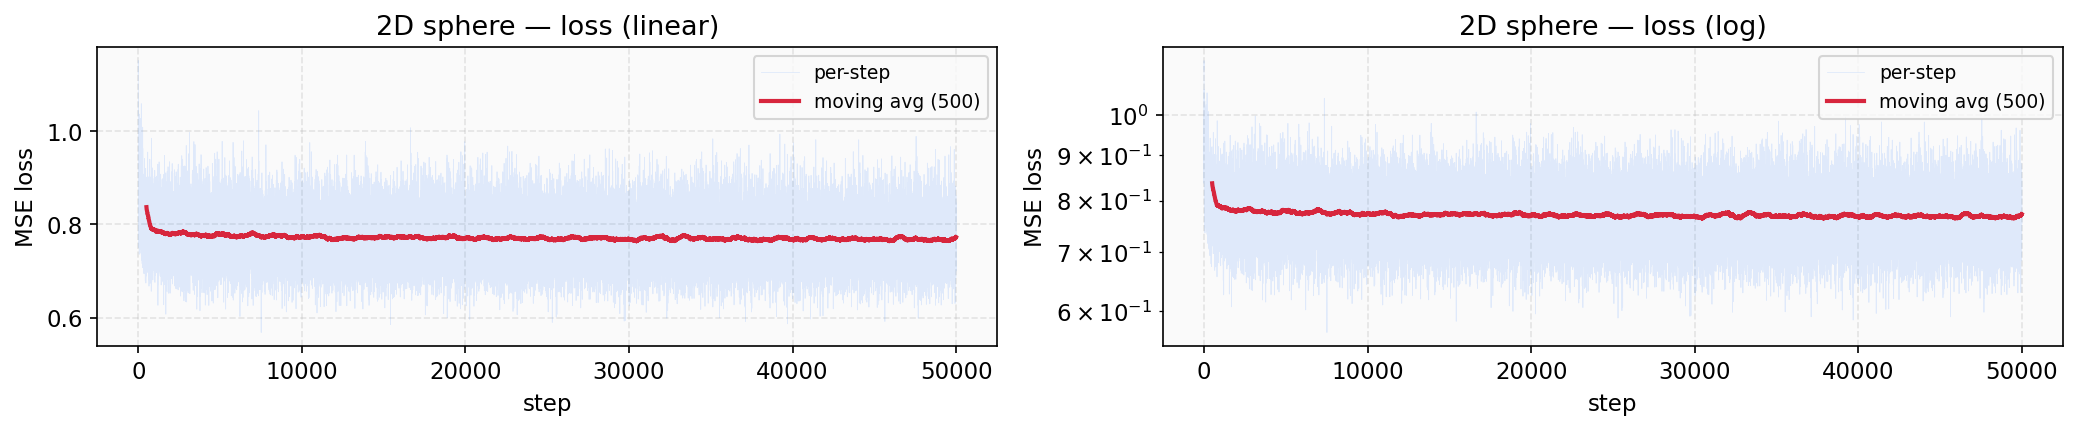

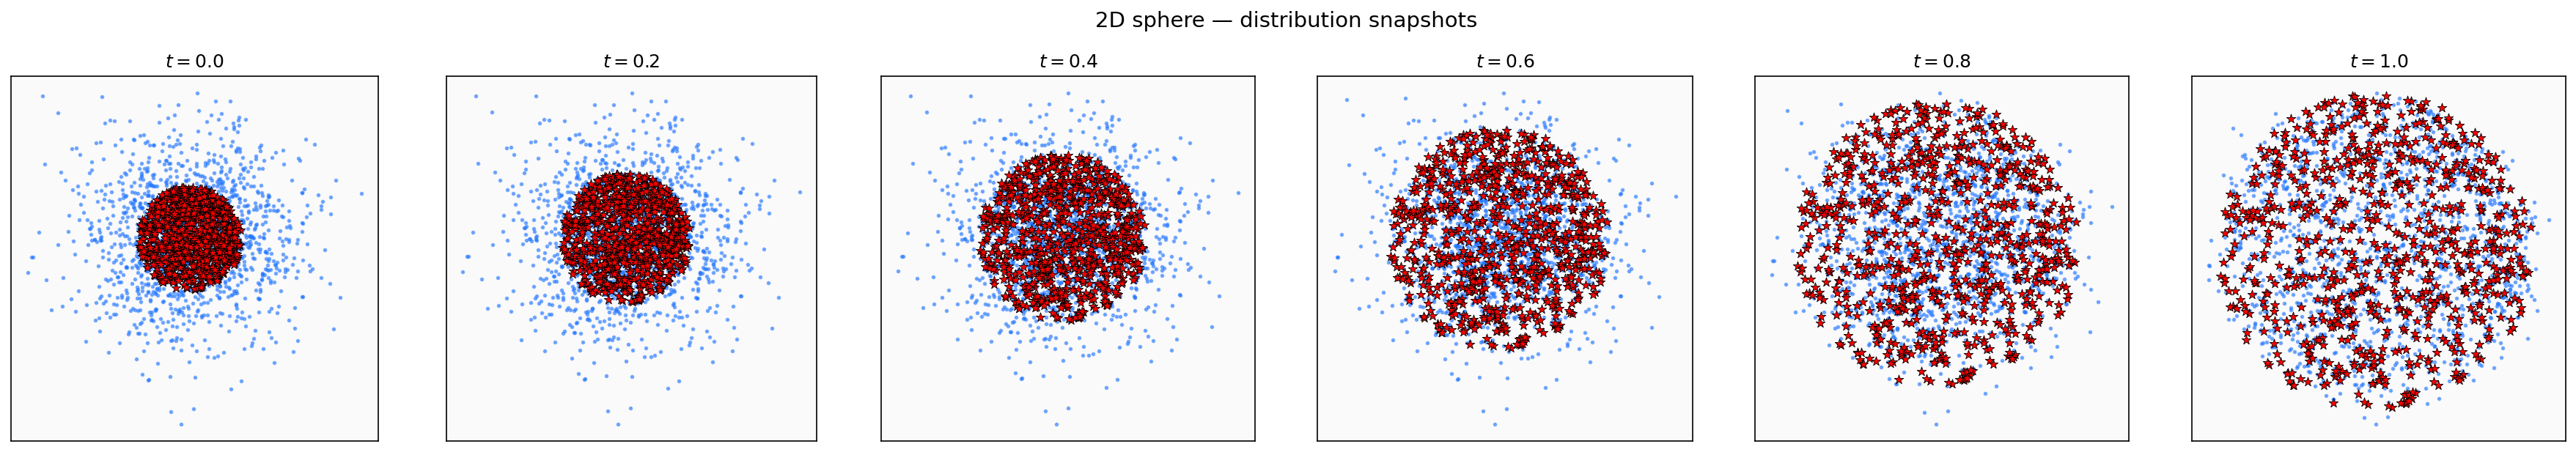

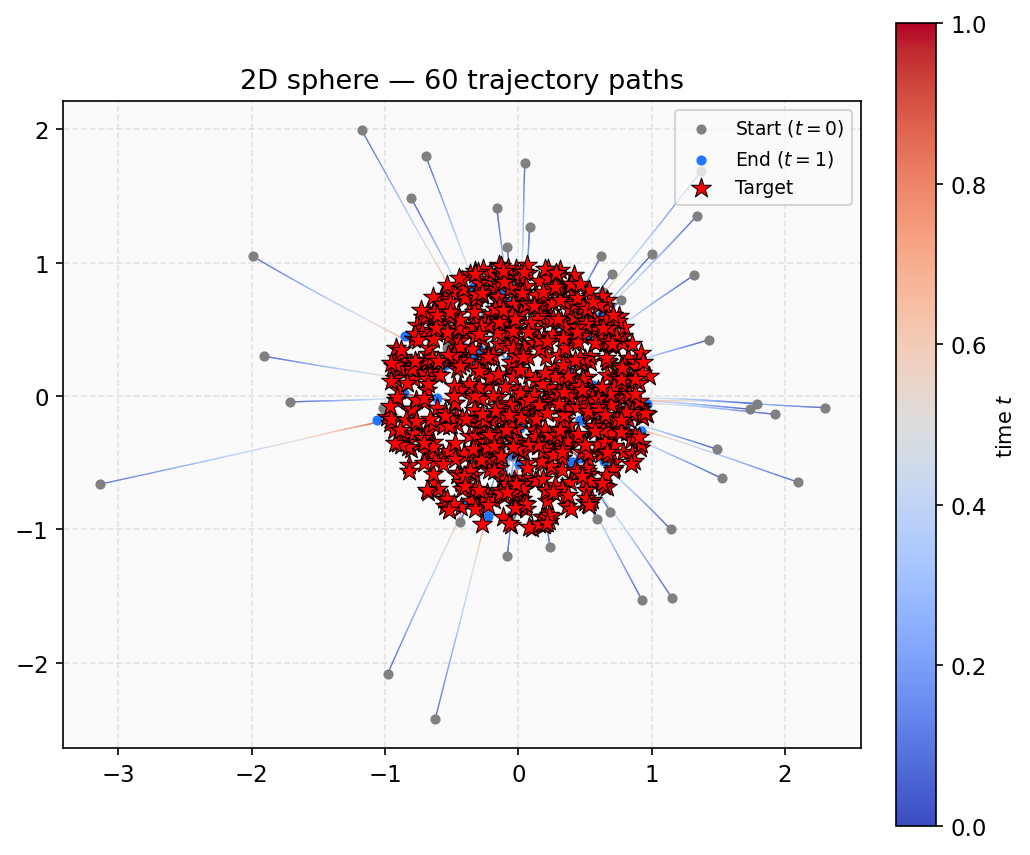

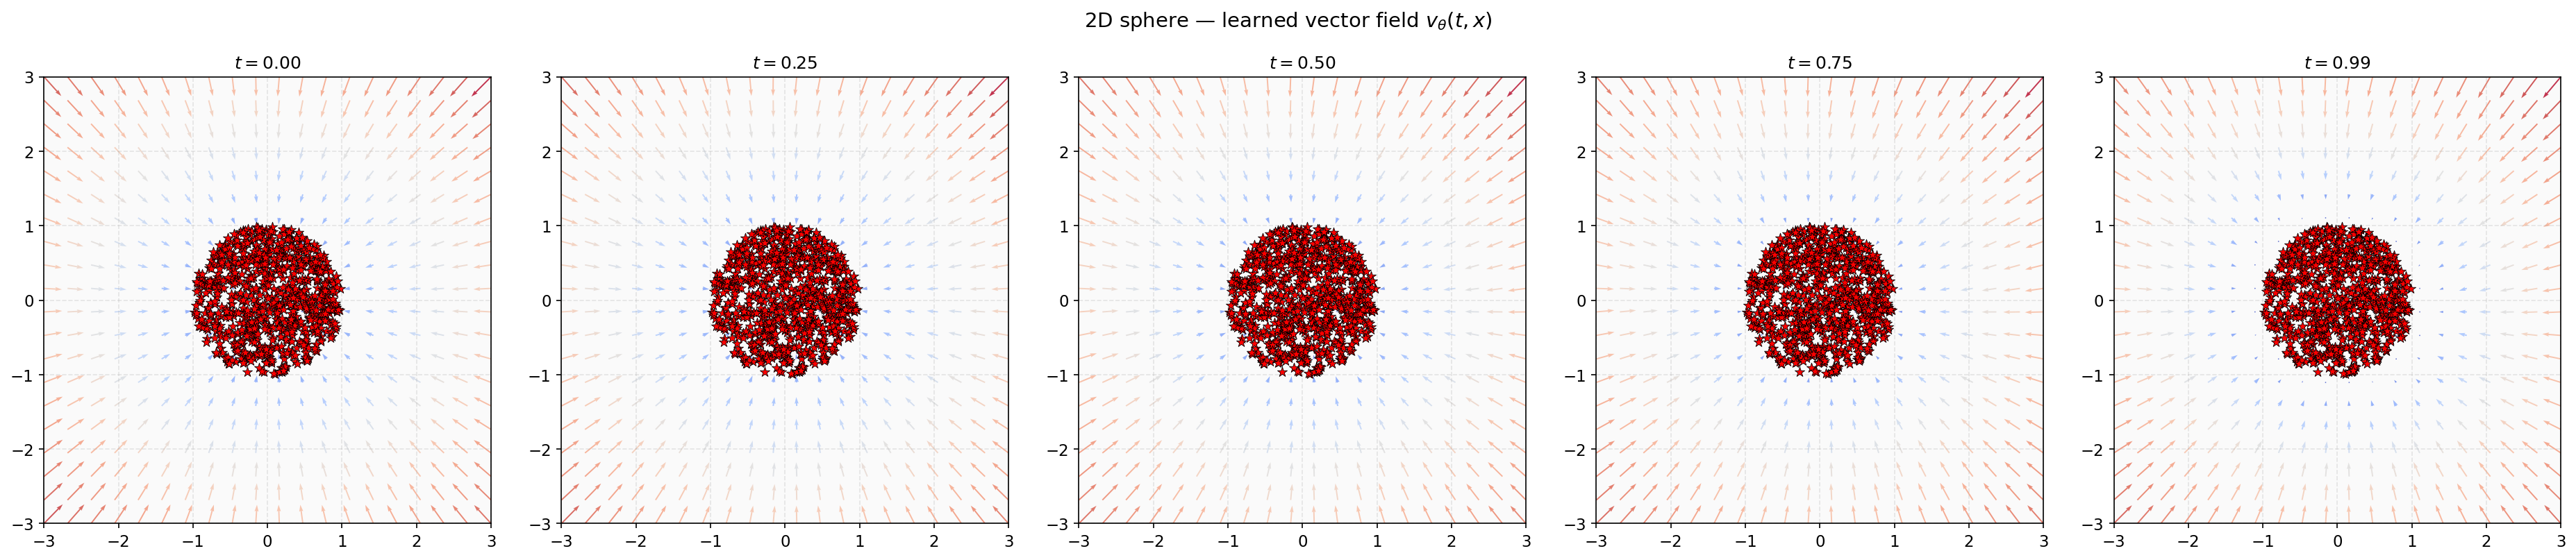

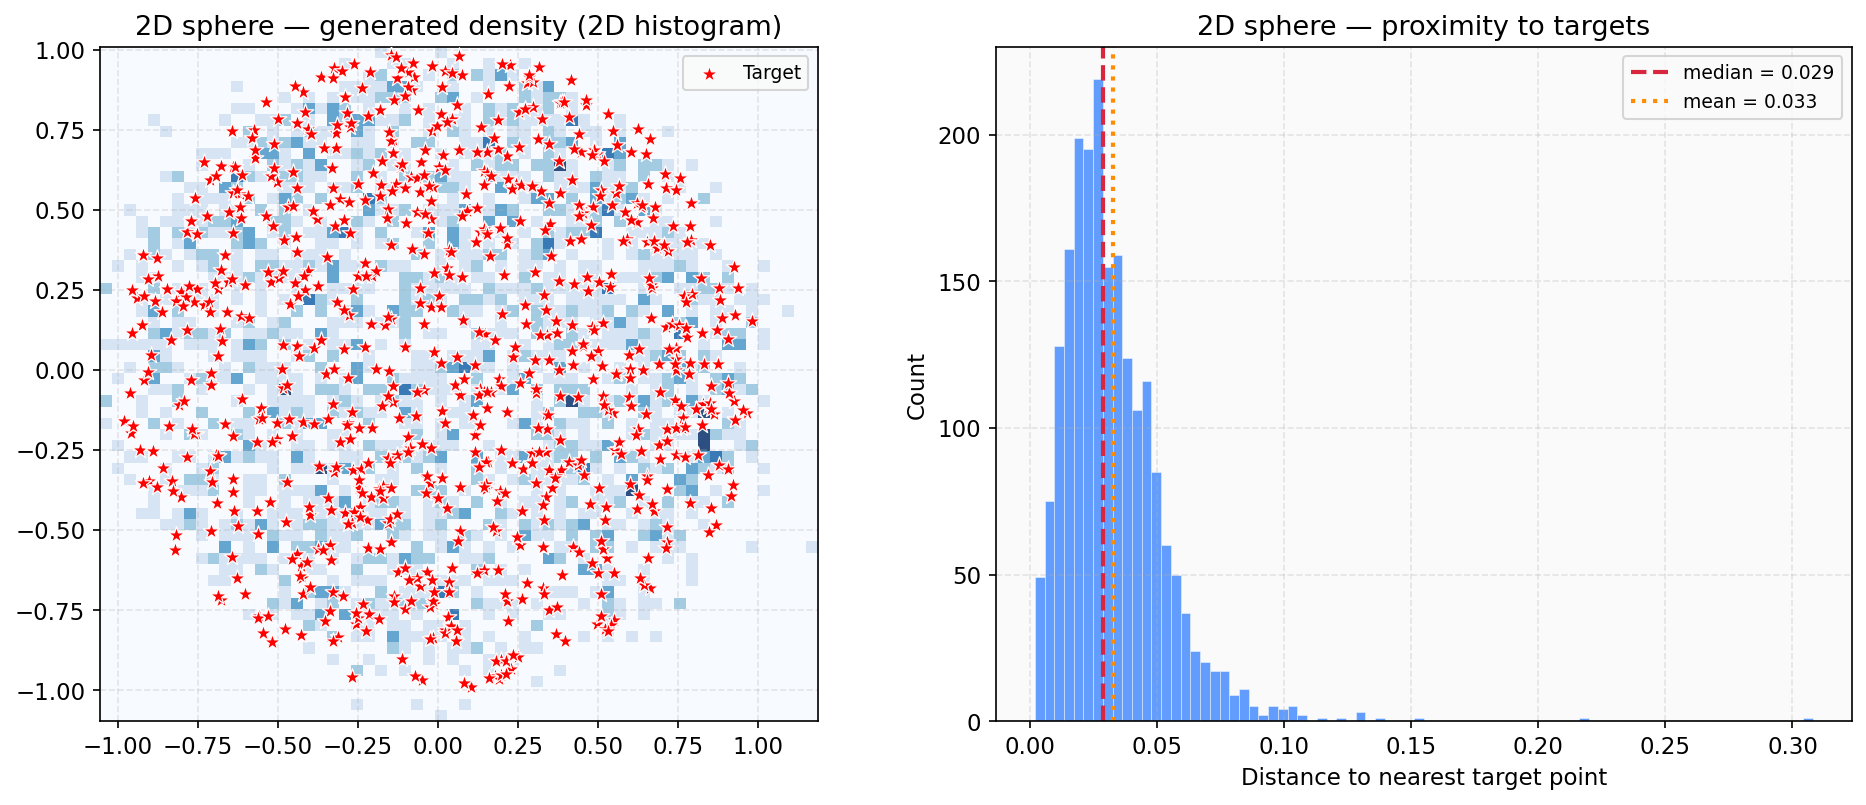

In [7]:
print("Training on 2D sphere (uniform disk) ...")
model_2, losses_2 = train(sample_2d_sphere)
traj_2 = generate(model_2)
plot_all(model_2, traj_2, xi_sphere, losses_2, "2D sphere")

---
## 3. Swiss roll

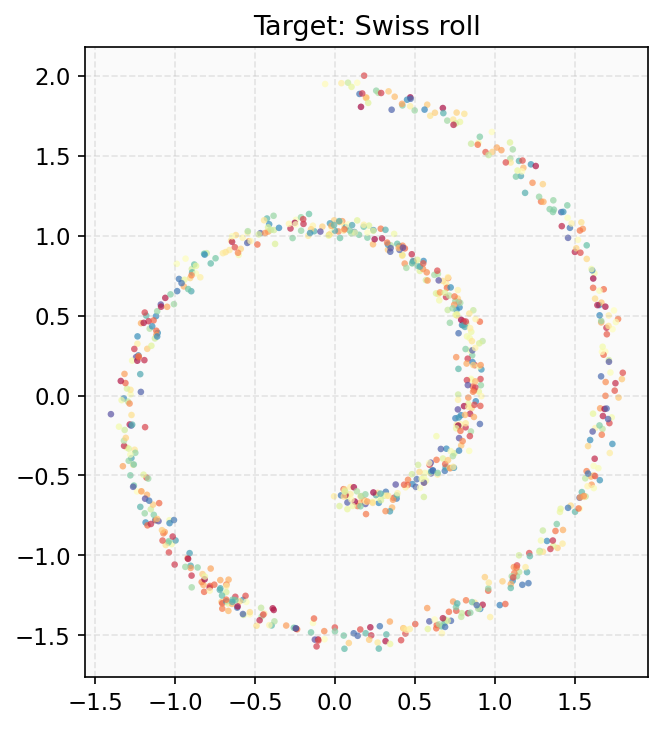

In [8]:
def sample_swiss_roll(n, noise=0.3):
    t = 1.5 * math.pi * (1 + 2 * torch.rand(n))
    x = t * torch.cos(t) + noise * torch.randn(n)
    y = t * torch.sin(t) + noise * torch.randn(n)
    pts = torch.stack([x, y], dim=1)
    return pts / pts.abs().max() * 2

xi_swiss_raw = sample_swiss_roll(800)
xi_swiss = xi_swiss_raw.numpy()

fig, ax = plt.subplots(figsize=(5, 5))
t_color = 1.5 * math.pi * (1 + 2 * torch.rand(800))
ax.scatter(xi_swiss[:, 0], xi_swiss[:, 1], s=10, c=t_color.numpy(),
           cmap="Spectral", alpha=0.7, edgecolors="none")
ax.set_aspect("equal")
ax.set_title("Target: Swiss roll")
plt.tight_layout(); plt.show()

Training on Swiss roll ...


  step   5000 | loss 1.3264 | 10.8s


  step  10000 | loss 1.3234 | 13.0s


  step  15000 | loss 1.4609 | 13.1s


  step  20000 | loss 1.2887 | 11.3s


...

  step  30000 | loss 1.3283 | 11.7s


  step  35000 | loss 1.4260 | 11.1s


  step  40000 | loss 1.4727 | 11.1s


  step  45000 | loss 1.3925 | 11.2s


  step  50000 | loss 1.5428 | 11.3s


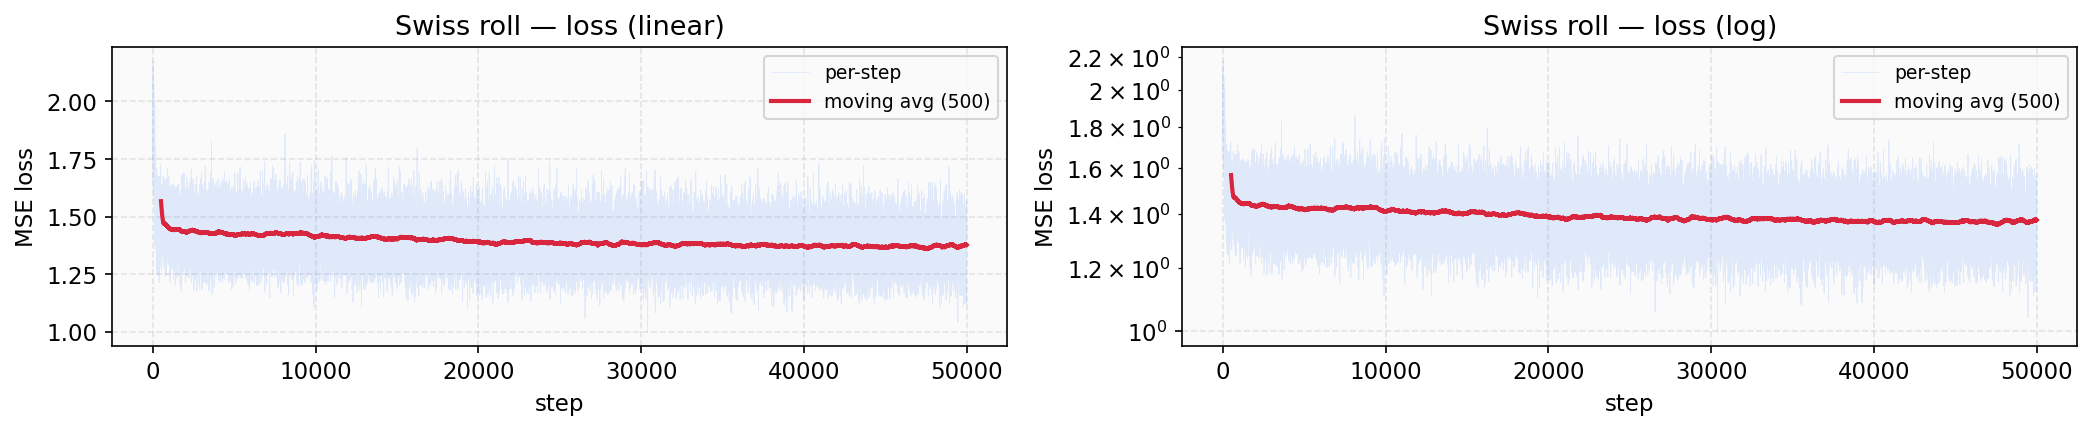

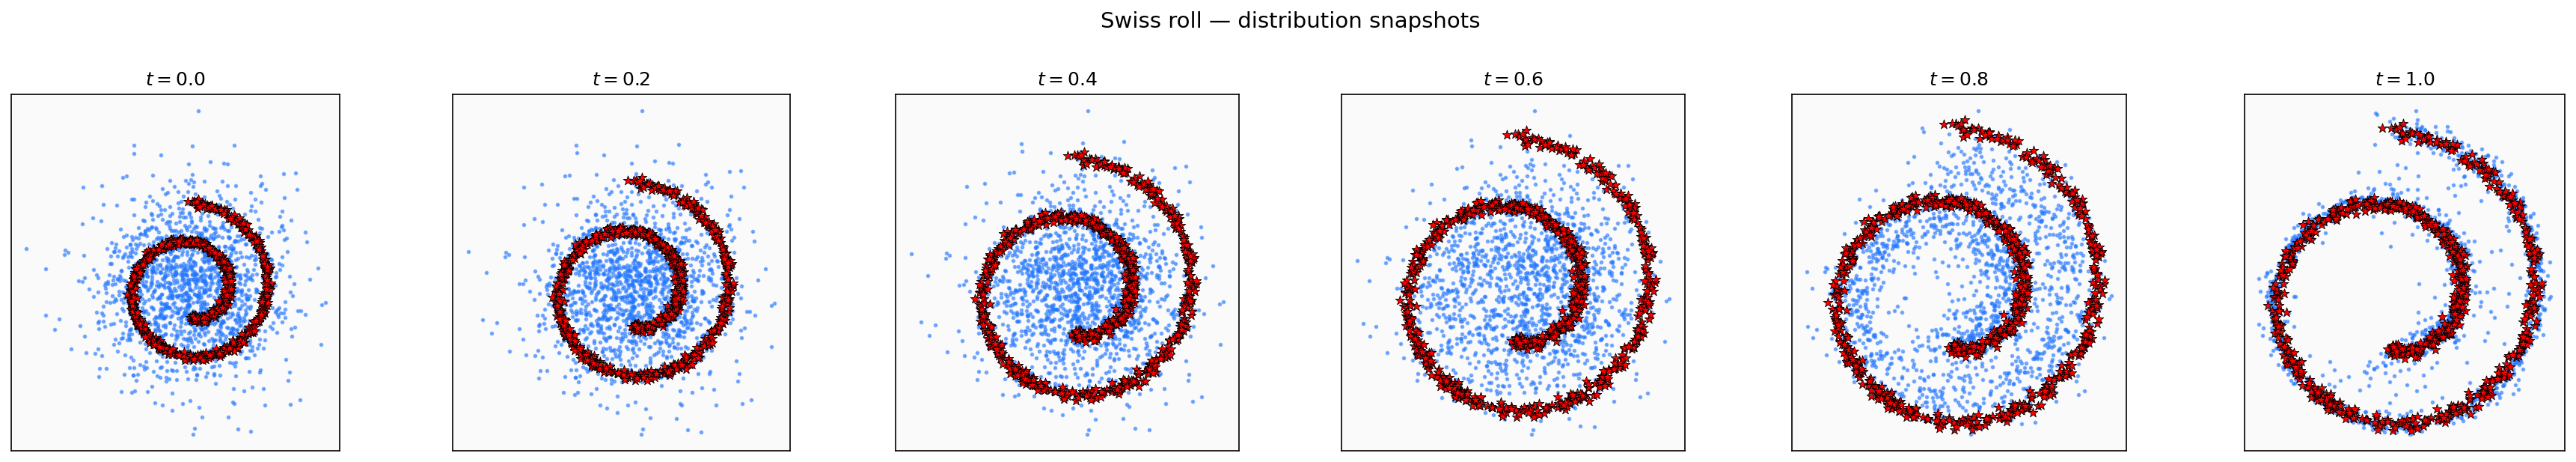

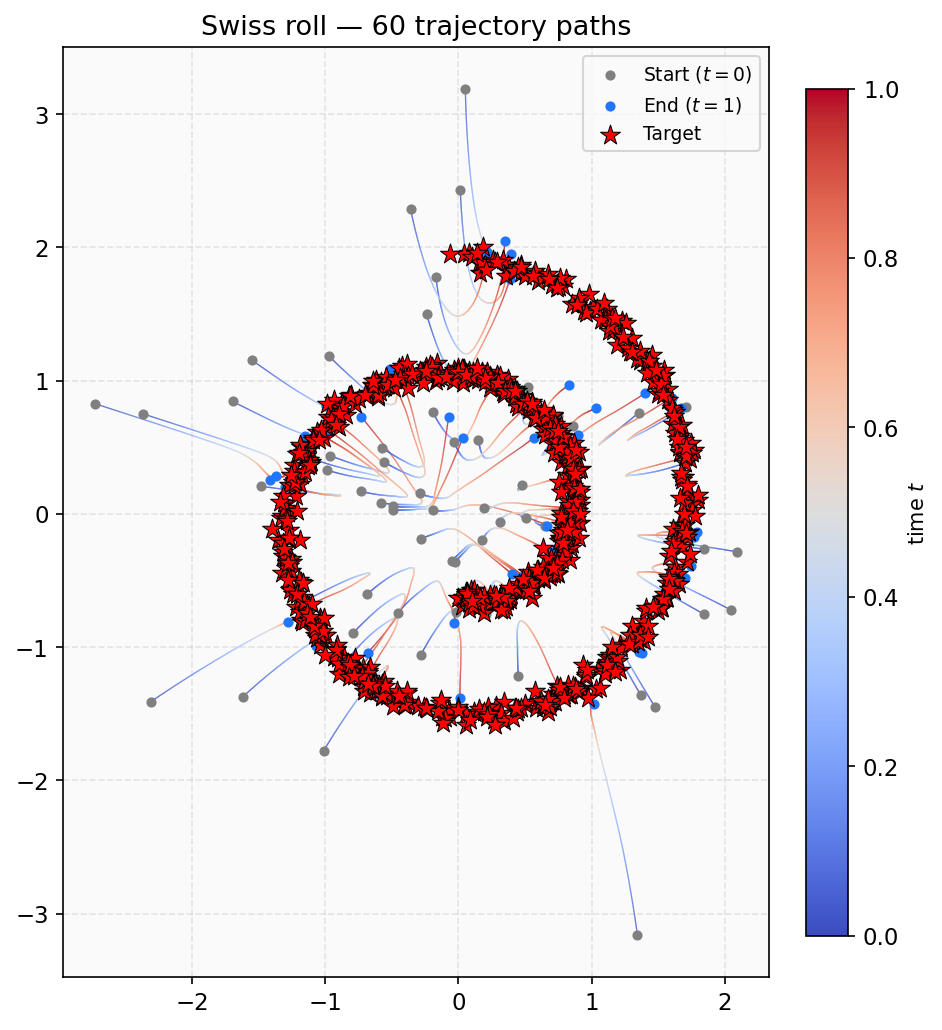

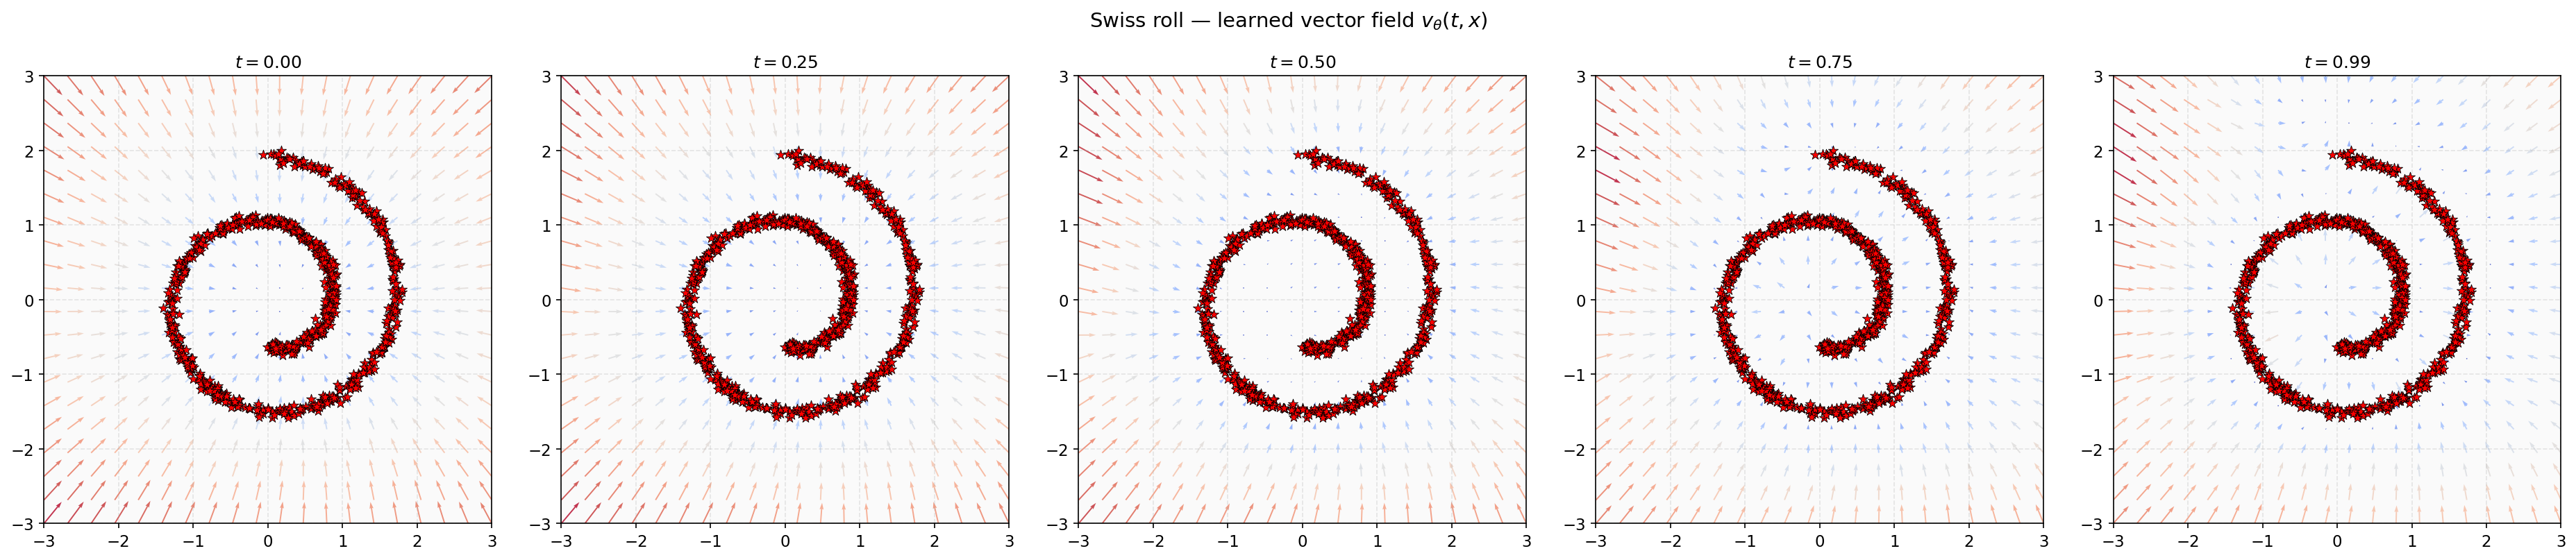

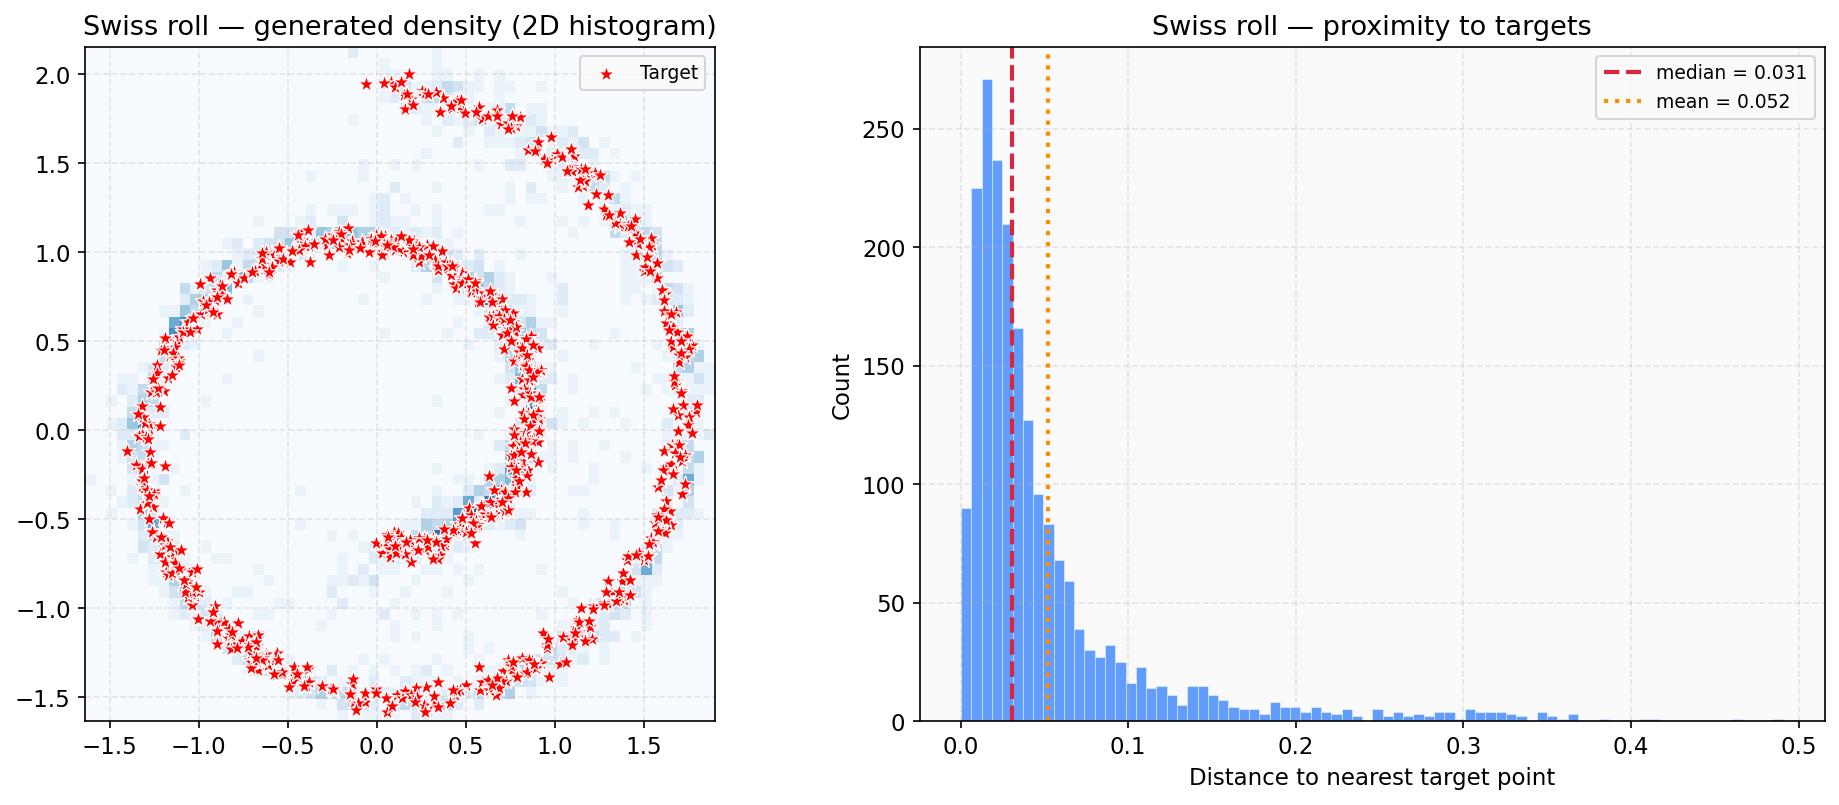

In [9]:
print("Training on Swiss roll ...")
model_3, losses_3 = train(sample_swiss_roll)
traj_3 = generate(model_3)
plot_all(model_3, traj_3, xi_swiss, losses_3, "Swiss roll")